

---


# Лабораторная работа 1

Выполнили:
* Полежаева Евгения (P4240)
* Солодкая Мария (P4240)



---



### Установка зависимостей

На первом шаге мы начинаем с установки необходимых библиотек. Пакет [gymnasium](https://en.wikipedia.org/wiki/Q-learning#Deep_Q-learning) предоставляет различные среды для обучения с подкреплением, в то время как [stable-baselines3](https://en.wikipedia.org/wiki/Q-learning#Deep_Q-learning) предоставляет реализации различных алгоритмов обучения с подкреплением.

In [1]:
# Установка необходимых библиотек
!pip install gym[atari]
!pip install autorom[accept-rom-license]
!pip install stable-baselines3
!pip install PyVirtualDisplay
!sudo apt-get install xvfb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 6.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.7/434.7 kB 3.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for AutoROM.accept-rom-license: filename=AutoROM.accept_rom_license-0.6.1-py3-none-any.whl size=446660 sha256=678b9ffeffe0a7681759c81f9ebf953329cfb2aa6702316a889eaec9c61d91b9
  Stored in directory: /root/.cache/pip/wheels/6b/1b/ef/a43ff1a2f1736d5711faa1ba4c1f61be1131b8899e6a057811
Successfully built AutoROM.accept-rom-license
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.7/181.7 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.9/953.9 kB 8.4 MB/s eta 0:00:00
  Using cached Farama_Notifications-0.0.4-py3-none-any.whl (2.5 kB)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional package

После установки мы импортируем два основных модуля: gym и [DQN](https://en.wikipedia.org/wiki/Q-learning#Deep_Q-learning) из stable_baselines3. gym предоставляет инструменты для создания и использования различных сред для обучения агента, в то время как DQN (Deep Q-Network) представляет собой алгоритм Q-learning с использованием нейронных сетей для оценки функции Q.

In [2]:
# Импорт необходимых пакетов
import gymnasium as gym
from stable_baselines3 import DQN

## Выбор среды


---


В данной работе мы будем использовать среду [FrozenLake](https://gymnasium.farama.org/environments/toy_text/frozen_lake/#frozen-lake), предоставляемую Gym. Эта задача заключается в пересечении замерзшего озера от старта до цели, не проваливаясь ни в какие ямы, проходя по замерзшему озеру. Игрок не всегда может двигаться в намеченном направлении из-за скользкого характера замерзшего озера.


---


### Создание среды FrozenLake

Мы используем метод `gym.make()` для создания среды с именем `'FrozenLake-v1'`. Эта среда предоставляет задачу с замерзшим озером.

**Параметры:**

* `desc=None`: Используется для указания карт без предварительной загрузки.

* `map_name="4x4"`: Идентификатор для использования любой из предварительно загруженных карт.

* `is_slippery=True`: Если значение true, игрок будет двигаться в намеченном направлении с вероятностью 1/3, остальные игроки будут двигаться в любом перпендикулярном направлении с равной вероятностью 1/3 в обоих направлениях.

Например, если действие оставлено, а значение `is_slippery` равно `True`, то:

P (движение влево) = 1/3

P (движение вверх) = 1/3

P (двигаться вниз) = 1/3


In [3]:
# Создание среды FrozenLake
env = gym.make('FrozenLake-v1', desc=None, map_name="4x4", is_slippery=True)

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


#### Описание задачи
Cохраняем информацию о пространстве наблюдений (observation_space) и пространстве действий (action_space). observation_space представляет собой пространство всех возможных состояний в задаче, а action_space - пространство всех возможных действий, которые агент может предпринять.

In [4]:
# Описание задачи
observation_space = env.observation_space
action_space = env.action_space

### Решение задачи


---


На этом шаге мы используем алгоритм Q-learning, представленный в stable-baselines3, для решения задачи FrozenLake. Давайте разберем каждый этап.


---



#### Инициализация модели DQN и обучение модели
* создаем экземпляр модели Deep Q-Network (DQN) с использованием `DQN("MlpPolicy", env, verbose=1)`. Здесь `"MlpPolicy"` означает полносвязную нейронную сеть в качестве политики. env - это среда FrozenLake, а verbose=1 добавляет вывод для отслеживания прогресса обучения.

* вызываем метод `learn()` для обучения модели на 100 временных шагах `(total_timesteps=100)`.


In [5]:
# Инициализация модели DQN
model = DQN("MlpPolicy", env, verbose=1)

# Обучение модели
timestamp=100
model.learn(total_timesteps=timestamp, log_interval=4)
model.save("dqn_frozenlake")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 5.75     |
|    ep_rew_mean      | 0        |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 4        |
|    fps              | 5055     |
|    time_elapsed     | 0        |
|    total_timesteps  | 23       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 4.5      |
|    ep_rew_mean      | 0        |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 8        |
|    fps              | 3925     |
|    time_elapsed     | 0        |
|    total_timesteps  | 36       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 5.5      |
|    ep_rew_mean      | 0      

#### Тестирование модели
Тестируем обученную модель, используя цикл, в котором агент принимает решения в соответствии с обученной политикой на каждом временном шаге. Мы используем метод `render()`, чтобы визуализировать среду в реальном времени.

Установка пакета Xvfb, который необходим для визуализации среды в Colab.

In [6]:
!sudo apt-get install xvfb

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
xvfb is already the newest version (2:21.1.4-2ubuntu1.7~22.04.5).
0 upgraded, 0 newly installed, 0 to remove and 24 not upgraded.


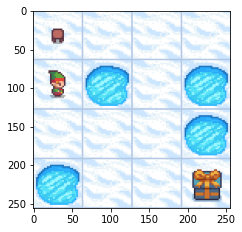

In [9]:
# библиотека, предоставляющая среду для обучения с подкреплением
import gym
import numpy as np
# модуль, отвечающий за отображение в блокнотах Jupyter
from IPython import display
# класс, позволяющий создавать виртуальные дисплеи для использования в виртуальных средах
from pyvirtualdisplay import Display
import matplotlib.pyplot as plt
from matplotlib import animation

# Создание экземпляра виртуального дисплея
d = Display()
# Запуск виртуального дисплея
d.start()

# Создание среды FrozenLake-v1 для тестирования
env = gym.make('FrozenLake-v1', desc=None, map_name="4x4", is_slippery=True)

# Сброс среды и получение начального наблюдения
obs = env.reset()

# Запись изображений для создания анимации
img = []
for _ in range(100):
    # Предсказание действия с использованием обученной модели
    action, _states = model.predict(obs, deterministic=True)

    # Применение действия к среде и получение нового наблюдения, вознаграждения, флага завершения и флага усечения
    obs, reward, terminated, truncated = env.step(int(action))

    # Очистка вывода для анимации
    display.clear_output(wait=True)
    # Запись текущего кадра среды в виде изображения
    img.append(env.render('rgb_array'))

    # Сброс среды (если используется виртуальный дисплей)
    if d:
        env.reset()

# Установка точек на дюйм (DPI) для создания изображения
dpi = 72
# Установка интервала обновления для анимации в мс
interval = 50

# Создание и отображение анимации с помощью matplotlib
plt.figure(figsize=(img[0].shape[1]/dpi,img[0].shape[0]/dpi),dpi=dpi)
patch = plt.imshow(img[0])
plt.axis=('off')
animate = lambda i: patch.set_data(img[i])
ani = animation.FuncAnimation(plt.gcf(),animate,frames=len(img),interval=interval)
display.display(display.HTML(ani.to_jshtml()))

#### Закрытие среды после тестирования
По завершении тестирования мы закрываем среду с помощью env.close().

In [10]:
# Закрытие среды после тестирования
env.close()

## Выводы:

1. Изучены новые библиотеки и зависимости (Gym, Stable-baselines3, PyVirtualDisplay и Xvfb). Они были использованы для создания среды и реализации алгоритма обучения с подкреплением на примере задачи FrozenLake-v1, а также визуализации результатов обучения в Colab с использованием анимации.
2. Изучен алгоритм DQN и использован для обучения модели глубокого обучения в среде FrozenLake-v1.
3. Для виртуализации окружения в Colab был использован виртуальный дисплей Xvfb, а также PyVirtualDisplay и Matplotlib, которые позволили отобразить результаты тестирования обученной модели в виде анимации.
4. Обученная модель была использована в задаче прогнозирования действий в среде FrozenLake-v1. Цикл, который это выполнял, записывал кадры среды в виде изображений, после чего была создана анимация.